In [33]:
import numpy as np
from scipy import stats
import plotly.figure_factory as ff

In [46]:
# Parameters for the multinomial distribution
n_trials = 100  # Total number of trials
p_true = [0.6, 0.3, 0.2]  # Probabilities for the three categories
alpha_prior = np.array([1.5, 1.5, 1.5])

# Generate a sample from the multinomial distribution
sample = multinomial.rvs(n=n_trials, p=p_true, size=1)[0]

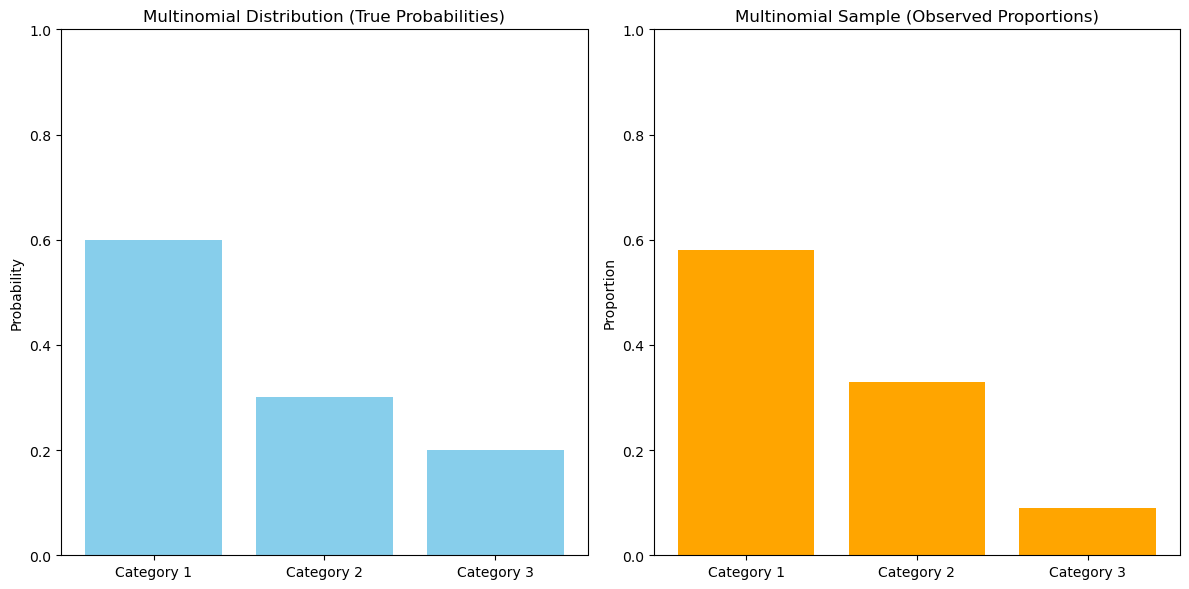

In [47]:
# Category labels
categories = ['Category 1', 'Category 2', 'Category 3']

# Visualization of the multinomial probabilities and the sample
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot the true probabilities
ax[0].bar(categories, p_true, color='skyblue')
ax[0].set_title('Multinomial Distribution (True Probabilities)')
ax[0].set_ylabel('Probability')
ax[0].set_ylim(0, 1)

# Plot the observed sample
ax[1].bar(categories, sample / n_trials, color='orange')
ax[1].set_title('Multinomial Sample (Observed Proportions)')
ax[1].set_ylabel('Proportion')
ax[1].set_ylim(0, 1)

# Display the plots
plt.tight_layout()
plt.show()


In [48]:
#Generate grid points for the simplex
p1 = np.linspace(0, 1, 100)
p2 = 1 - p1.copy()
p_ = np.linspace(0, 1, 100)
p1 = (p1[np.newaxis, :] * p_[:, np.newaxis]).flatten()
p2 = (p2[np.newaxis, :] * p_[:, np.newaxis]).flatten()
p3 = 1 - p1 - p2
p = np.c_[p1, p2, p3]

# Remove invalid points where p1 + p2 + p3 > 1 or any probabilities are negative
p = p[(p >= 0).all(axis=1) & (p.sum(axis=1) <= 1)]




In [49]:
#Create Dirichlet distributions (prior and posterior)
dirichlet_prior = stats.dirichlet(alpha=alpha_prior)
dirichlet_posterior = stats.dirichlet(alpha=alpha_posterior)

dirichlet_prior_densities = dirichlet_prior.pdf(p.T)
dirichlet_posterior_densities = dirichlet_posterior.pdf(p.T)

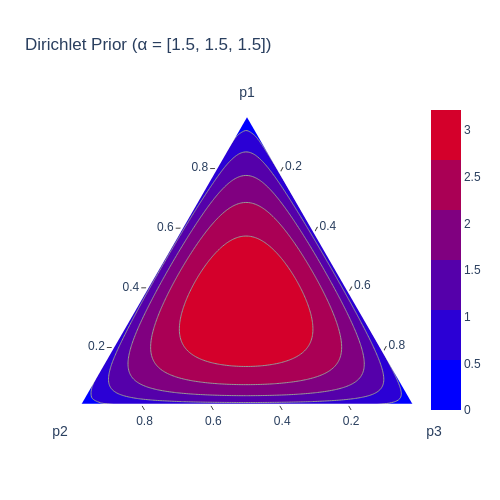

In [54]:
#Visualize the Dirichlet prior
fig_prior = ff.create_ternary_contour(
    p.T,
    dirichlet_prior_densities,
    pole_labels=["p1", "p2", "p3"],
    interp_mode="cartesian",
    showscale=True,
)
fig_prior.update_layout(title="Dirichlet Prior (α = [1.5, 1.5, 1.5])")
fig_prior.show('png')

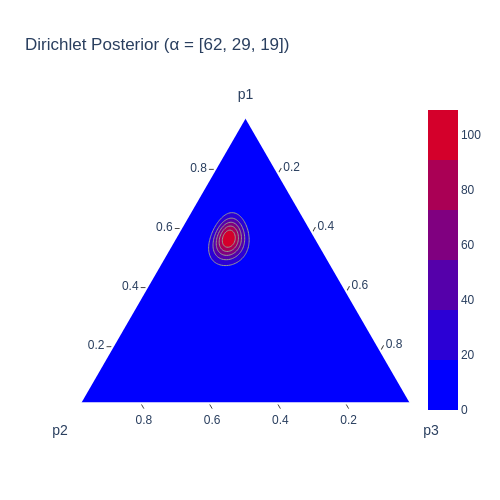

In [56]:
#Visualize the Dirichlet posterior
fig_posterior = ff.create_ternary_contour(
    p.T,
    dirichlet_posterior_densities,
    pole_labels=["p1", "p2", "p3"],
    interp_mode="cartesian",
    showscale=True,
)
fig_posterior.update_layout(title=f"Dirichlet Posterior (α = {alpha_posterior.tolist()})")
fig_posterior.show('png')